In [1]:
from pathlib import Path
import sys
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [2]:
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from datasets.atlas import ATLAS
from collections import Counter
from scipy.ndimage import label
from matplotlib.colors import ListedColormap
import SimpleITK as sitk
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from tqdm import tqdm
from radiomics import featureextractor
import shutil

from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline

from fsl.wrappers import bet
from pathlib import Path
import tempfile

In [3]:
DBB_DATASET_FOLDER = "/run/media/gianluca/Hard_drive/DBB"
ATLAS_PREPROCESSED_DATASET_FOLDER = "/run/media/gianluca/Hard_drive/ATLAS_R3.0_preprocessed"

In [4]:
from ipywidgets import interact, IntSlider, Dropdown
import ipywidgets as widgets
import scipy
from skimage.segmentation import find_boundaries


def explore_mri(img, mask, canonical=False, rotation=False, connected_components=False, show_boundaries=False):
    """
    :param img: filepath or nib or array
    :param mask: filepath or nib or array
    :param canonical: whether to use canonical RAS orientation
    :param rotation: wheter to rotate both the image and mask 90 degreees counter-clockwise
    :param connected_components: wheter to detect the connected components of the mask and treat them as different items
    :param show_boundaries: whetever to show only the boundaries of the mask instead of all its pixels
    """
    def get_data(src):
        if isinstance(src, str): # filepath
            nifti_data = nib.load(src)
            if canonical:
                nifti_data = nib.as_closest_canonical(nifti_data)
            data = nifti_data.get_fdata()
        elif isinstance(src, nib.Nifti1Image): # niftiimage
            data = src.get_fdata()
        else:
            data = np.asarray(src) # generic numpy array

        return data
    
    # Get data for image and mask
    img = get_data(img)
    mask = get_data(mask)
    
    # define dropdown menu selection for the plane of view
    plane_widget = Dropdown(
        options=["Sagittal", "Coronal", "Axial"],
        value="Axial",
        description="Plane:"
    )

    # define the slider for the images
    slice_slider = IntSlider(
        min=0,
        max=img.shape[2]-1,
        step=1,
        value=img.shape[2] // 2,
        description="Slice:",
        continuos_upldate=False
    )

    def update_slider(*args):
        plane = plane_widget.value

        if plane == "Axial":
            n_slices = img.shape[2]
        elif plane == "Coronal":
            n_slices = img.shape[1]
        else:  # Sagittal
            n_slices = img.shape[0]

        # determine maximum and minimum range by the number of slices available
        slice_slider.max = n_slices - 1
        slice_slider.value = n_slices // 2

    plane_widget.observe(update_slider, names="value")

    # find connected components in the segmentation mask
    if connected_components:
        labeled_mask, num_features = label(mask)
        colors = plt.cm.tab10(np.linspace(0,1,num_features))
        colors = np.vstack([[0,0,0,0],colors])
        cmap = ListedColormap(colors)

    def show_slice(plane, slice_idx):
        fig, ax = plt.subplots(figsize=(10,10))

        if plane == "Axial":
            img_slice = img[:, :, slice_idx]
            mask_slice = mask[:, :, slice_idx] if not connected_components else labeled_mask[:,:, slice_idx]

        elif plane == "Coronal":
            img_slice = img[:, slice_idx, :]
            mask_slice = mask[:, slice_idx, :] if not connected_components else labeled_mask[:, slice_idx, :]

        elif plane == "Sagittal":
            img_slice = img[slice_idx, :, :]
            mask_slice = mask[slice_idx, :, :] if not connected_components else labeled_mask[slice_idx,:, :]

        # apply rotation
        if rotation:
            img_slice = np.rot90(img_slice)
            mask_slice = np.rot90(mask_slice)

        # determine lesion boundaries
        if show_boundaries:
            boundary = find_boundaries(mask_slice)
            mask_slice = np.where(boundary, mask_slice, 0)
        
        ax.imshow(img_slice, cmap="grey")
        
        if not connected_components:
            ax.imshow(mask_slice, alpha=(mask_slice > 0).astype(float))
        else:
            ax.imshow(mask_slice, alpha=(mask_slice > 0).astype(float), cmap=cmap, vmin=0, vmax=num_features)
            
        ax.set_title(f"Slice {slice_idx}")
        plt.show()

    # define dropdown and slicer interface
    ui = widgets.HBox([plane_widget, slice_slider])
    out = widgets.interactive_output(
        show_slice,
        {
            "plane": plane_widget,
            "slice_idx": slice_slider
        }
    )

    display(ui, out)

# ATLAS 3.0

In [5]:
df = ATLAS.get_metadata(ATLAS_PREPROCESSED_DATASET_FOLDER)
df.head(5)

,SESSION ID,DATASET,DAYS POST STROKE,CHRONICITY,SITE,T1W FILEPATH,SEGMENTATION FILEPATH
0,sub-r001s001_ses-1,Training,471.0,NaN,R001,ATLAS3_Training_Preprocessed/R001/sub-r001s001...,ATLAS3_Training_Preprocessed/R001/sub-r001s001...
1,sub-r001s002_ses-1,Training,669.0,NaN,R001,ATLAS3_Training_Preprocessed/R001/sub-r001s002...,ATLAS3_Training_Preprocessed/R001/sub-r001s002...
2,sub-r001s003_ses-1,Training,709.0,NaN,R001,ATLAS3_Training_Preprocessed/R001/sub-r001s003...,ATLAS3_Training_Preprocessed/R001/sub-r001s003...
3,sub-r001s004_ses-1,Training,871.0,NaN,R001,ATLAS3_Training_Preprocessed/R001/sub-r001s004...,ATLAS3_Training_Preprocessed/R001/sub-r001s004...
4,sub-r001s005_ses-1,Training,1917.0,NaN,R001,ATLAS3_Training_Preprocessed/R001/sub-r001s005...,ATLAS3_Training_Preprocessed/R001/sub-r001s005...


In [6]:
atlas2_df = df[df["DATASET"] != "ATLAS3"]

t1w_non_nan_filepath_count = atlas2_df['SEGMENTATION FILEPATH'].count()
segmentation_non_nan_filepath_count = atlas2_df['SEGMENTATION FILEPATH'].count()

print(f"T1W available: {t1w_non_nan_filepath_count}")
print(f"Segmentations available: {segmentation_non_nan_filepath_count}")

T1W available: 957
Segmentations available: 957


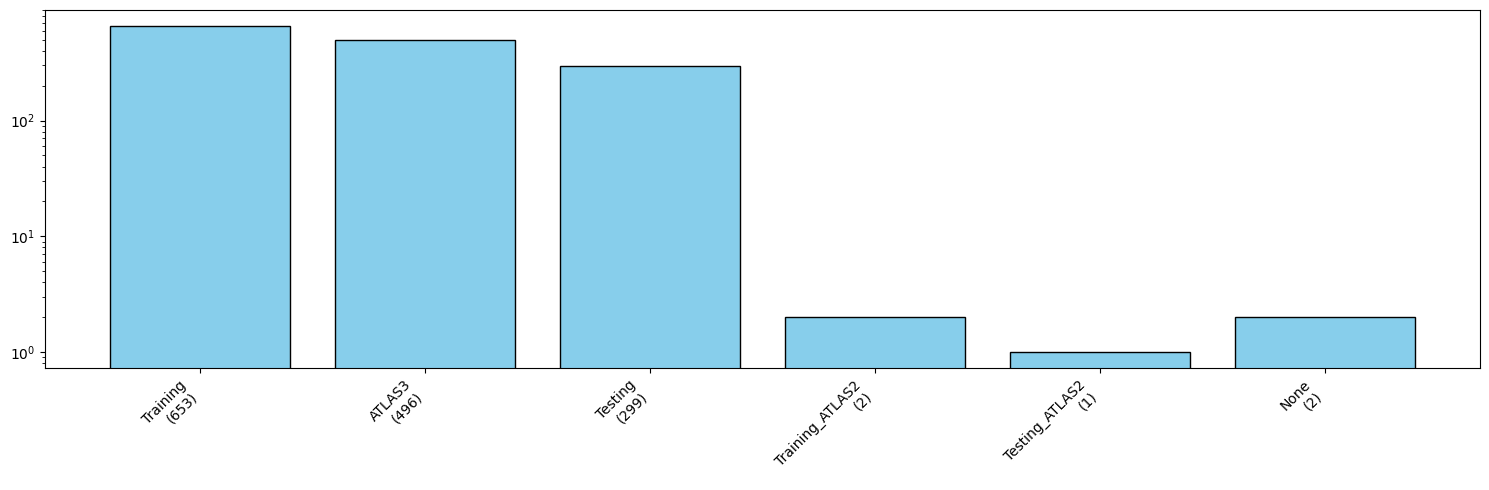

In [7]:
counts = Counter(df["DATASET"])
keys = [f"{key}\n({value})" if key is not None else f"None\n({value})" for key, value in counts.items()]

fig, ax = plt.subplots(figsize=(15,5))
ax.bar(keys, counts.values(), color='skyblue', edgecolor='black')
ax.set_yscale("log")
plt.xticks(rotation=45, ha="right")

plt.tight_layout() 
plt.show()

In [8]:
row = df.iloc()[0]

t1w_nib = nib.load(f"{ATLAS_PREPROCESSED_DATASET_FOLDER}/{row['T1W FILEPATH']}")
mask_nib = nib.load(f"{ATLAS_PREPROCESSED_DATASET_FOLDER}/{row['SEGMENTATION FILEPATH']}")

explore_mri(t1w_nib, mask_nib, connected_components=True, show_boundaries=True)

Output()

## Compare available resolutions

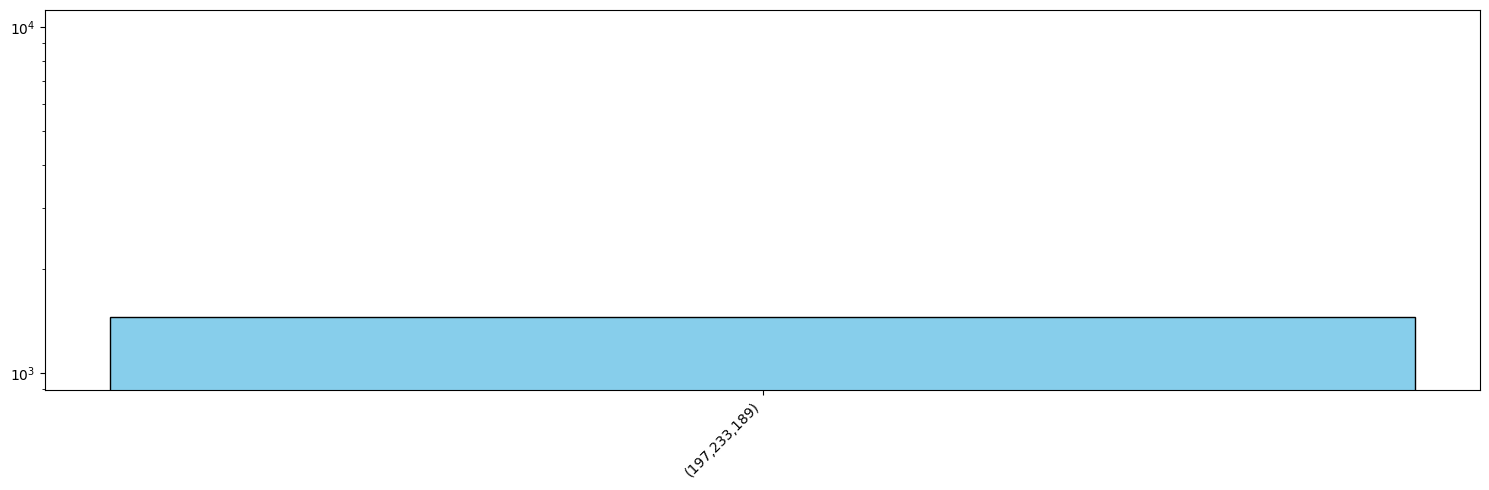

In [6]:
shapes = [
    nib.load(f"{ATLAS_PREPROCESSED_DATASET_FOLDER}/{t1w_filepath}").shape
    for t1w_filepath in df["T1W FILEPATH"]
]


counts = Counter(shapes)

fig, ax = plt.subplots(figsize=(15,5))
ax.bar([ f"({v[0]},{v[1]},{v[2]})" for v in counts.keys()], counts.values(), color='skyblue', edgecolor='black')
ax.set_yscale("log")
plt.xticks(rotation=45, ha="right")

plt.tight_layout() 
plt.show()

## Voxel size

In [10]:
voxel_sizes = np.array([
    nib.load(f"{ATLAS_PREPROCESSED_DATASET_FOLDER}/{t1w_filepath}").header.get_zooms()
    for t1w_filepath in df["T1W FILEPATH"]
])

t1_x_mean, t1_x_std = np.mean(voxel_sizes[:,0]), np.std(voxel_sizes[:,0])
t1_y_mean, t1_y_std = np.mean(voxel_sizes[:,1]), np.std(voxel_sizes[:,1])
t1_z_mean, t1_z_std = np.mean(voxel_sizes[:,2]), np.std(voxel_sizes[:,2])
print(f"[T1] ({t1_x_mean:.2f}±{t1_x_std:.2f}, {t1_y_mean:.2f}±{t1_y_std:.2f}, {t1_z_mean:.2f}±{t1_z_std:.2f})")

[T1] (1.00±0.00, 1.00±0.00, 1.00±0.00)


## Orientation

In [11]:
orientations = [
    "".join(nib.aff2axcodes(nib.load(f"{ATLAS_PREPROCESSED_DATASET_FOLDER}/{t1w_filepath}").affine))
    for t1w_filepath in df["T1W FILEPATH"]
]

print(np.unique_counts(orientations))

UniqueCountsResult(values=array(['RAS'], dtype='<U3'), counts=array([1453]))


## Exploring intensity histograms

### Subject 001 Site R001

In [9]:
row = df.iloc()[0]

t1w_filepath = f"{ATLAS_PREPROCESSED_DATASET_FOLDER}/{row['T1W FILEPATH']}"
t1w_array = nib.load(t1w_filepath).get_fdata()

Removing background voxels

In [10]:
mask = t1w_array > 0
t1w_no_background_array = t1w_array[mask]

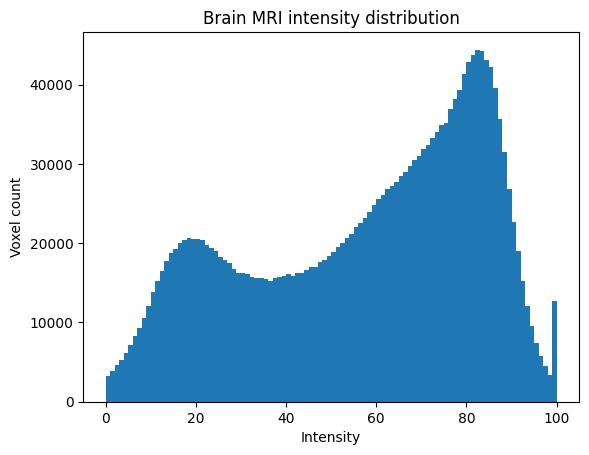

In [11]:
plt.hist(t1w_no_background_array, bins=100) 
plt.xlabel("Intensity")
plt.ylabel("Voxel count")
plt.title("Brain MRI intensity distribution")
plt.show()

Looking at percentiles and plotting the histogram restrictived to 1-99%

In [12]:
percentiles = np.percentile(
    t1w_no_background_array,
    [0, 1, 5, 25, 50, 75, 95, 99, 99.9, 100]
)

for key, value in zip([0, 1, 5, 25, 50, 75, 95, 99, 99.9, 100], percentiles):
    print(f"{key:4}%: {value:.2f}")

   0%: 0.00
   1%: 4.72
   5%: 12.43
  25%: 35.89
  50%: 63.13
  75%: 79.38
  95%: 90.25
  99%: 96.85
99.9%: 100.00
 100%: 100.00


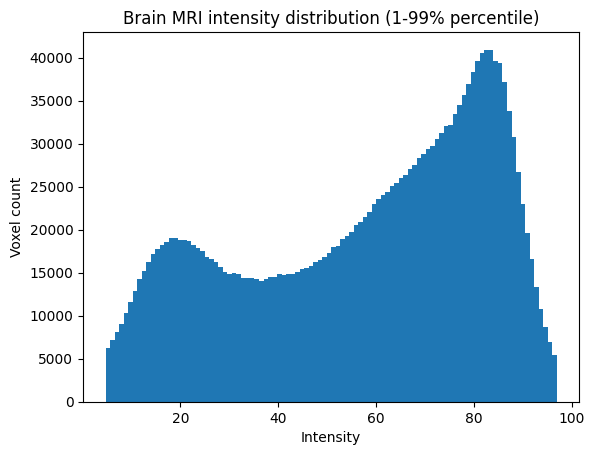

In [13]:
p1, p99 = percentiles[1], percentiles[-3]

plt.hist(t1w_no_background_array, bins=100, range=(p1, p99)) 
plt.xlabel("Intensity")
plt.ylabel("Voxel count")
plt.title("Brain MRI intensity distribution (1-99% percentile)")
plt.show()

N4 bias field correction

In [22]:
# load array as sitk image (consider that sitk uses different axes order)
t1w_sitk_image = sitk.GetImageFromArray(t1w_array)

# Create a mask
# mask = sitk.OtsuThreshold(t1w_sitk_image, 0, 1, 200)
sitk_image = sitk.GetImageFromArray((t1w_array > 0).astype(np.uint8))

# N4 correction
corrector = sitk.N4BiasFieldCorrectionImageFilter()
t1w_n4_bias_corrected_sitk_image = corrector.Execute(t1w_sitk_image, sitk_image)

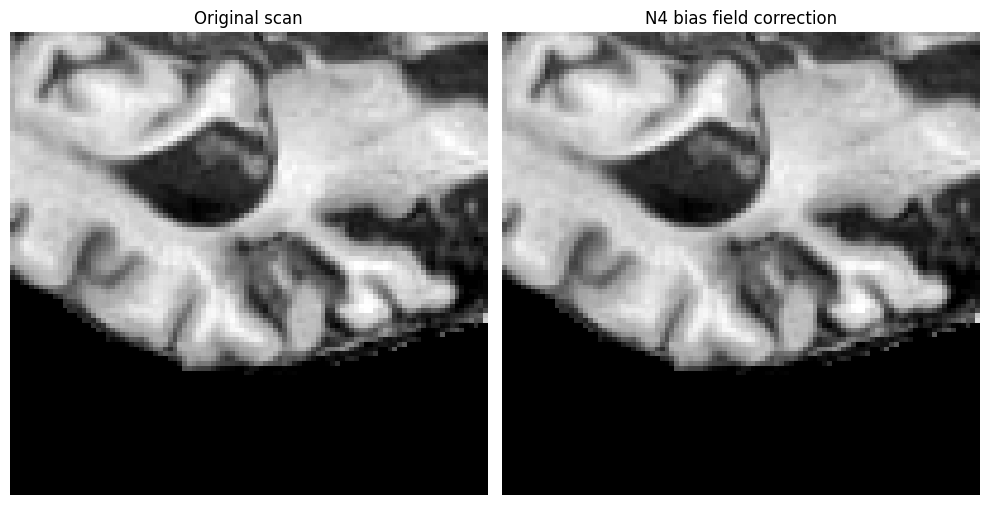

In [33]:
t1w_n4_bias_corrected_array = sitk.GetArrayFromImage(t1w_n4_bias_corrected_sitk_image)

fig, axes = plt.subplots(1,2, figsize=(10,5))

axes[0].imshow(t1w_array[100:200, 50:150, 73], cmap="gray")
axes[0].set_title("Original scan")
axes[0].set_axis_off()

axes[1].imshow(t1w_n4_bias_corrected_array[100:200, 50:150, 73], cmap="gray")
axes[1].set_title("N4 bias field correction")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

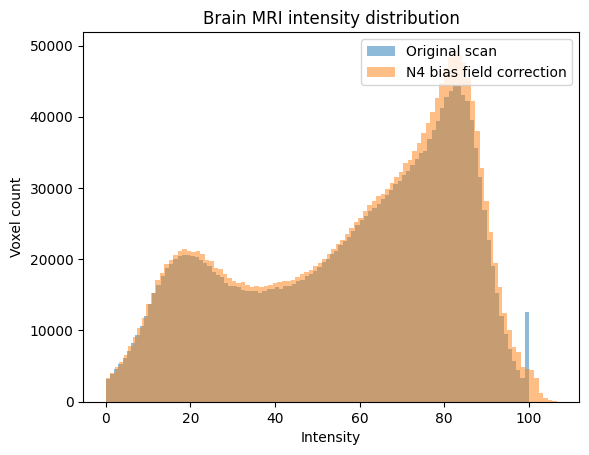

In [40]:
mask = t1w_n4_bias_corrected_array > 0
t1w_n4_bias_corrected_no_background_array = t1w_n4_bias_corrected_array[mask]

plt.hist(t1w_no_background_array, bins=100, alpha=0.5, label="Original scan") 
plt.hist(t1w_n4_bias_corrected_no_background_array, bins=100, alpha=0.5, label="N4 bias field correction")

plt.xlabel("Intensity")
plt.ylabel("Voxel count")
plt.title("Brain MRI intensity distribution")
plt.legend(loc="upper left")
plt.show()

Robust Normalization

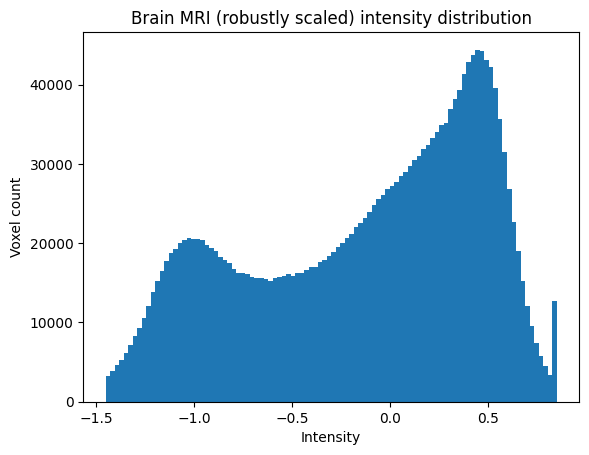

In [61]:
t1w_no_background_robustly_scaled = RobustScaler().fit_transform(t1w_no_background_array.reshape(-1, 1))

plt.hist(t1w_no_background_robustly_scaled, bins=100) 
plt.xlabel("Intensity")
plt.ylabel("Voxel count")
plt.title("Brain MRI (robustly scaled) intensity distribution")
plt.show()

### Performing robust scaling on 10 random patients and compare two different sites

In [15]:
site_r001 = {}
site_r002 = {}

for _, row in df[df["SITE"] == "R001"].sample(10, random_state=0).iterrows():
    patient_id = row['SESSION ID']
    t1w_filepath = f"{ATLAS_PREPROCESSED_DATASET_FOLDER}/{row['T1W FILEPATH']}"

    t1w_array = nib.load(t1w_filepath).get_fdata()
    mask = (t1w_array > 0)

    brain_array = t1w_array[mask].reshape(-1, 1)

    # perform robust scaling
    t1w_robust_scaling_array = RobustScaler().fit_transform(brain_array)

    site_r001[patient_id] = t1w_robust_scaling_array

for _, row in df[df["SITE"] == "R002"].sample(10, random_state=0).iterrows():
    patient_id = row['SESSION ID']
    t1w_filepath = f"{ATLAS_PREPROCESSED_DATASET_FOLDER}/{row['T1W FILEPATH']}"

    t1w_array = nib.load(t1w_filepath).get_fdata()
    mask = (t1w_array > 0)

    brain_array = t1w_array[mask].reshape(-1, 1)

    # perform robust scaling
    t1w_robust_scaling_array = RobustScaler().fit_transform(brain_array)

    site_r002[patient_id] = t1w_robust_scaling_array

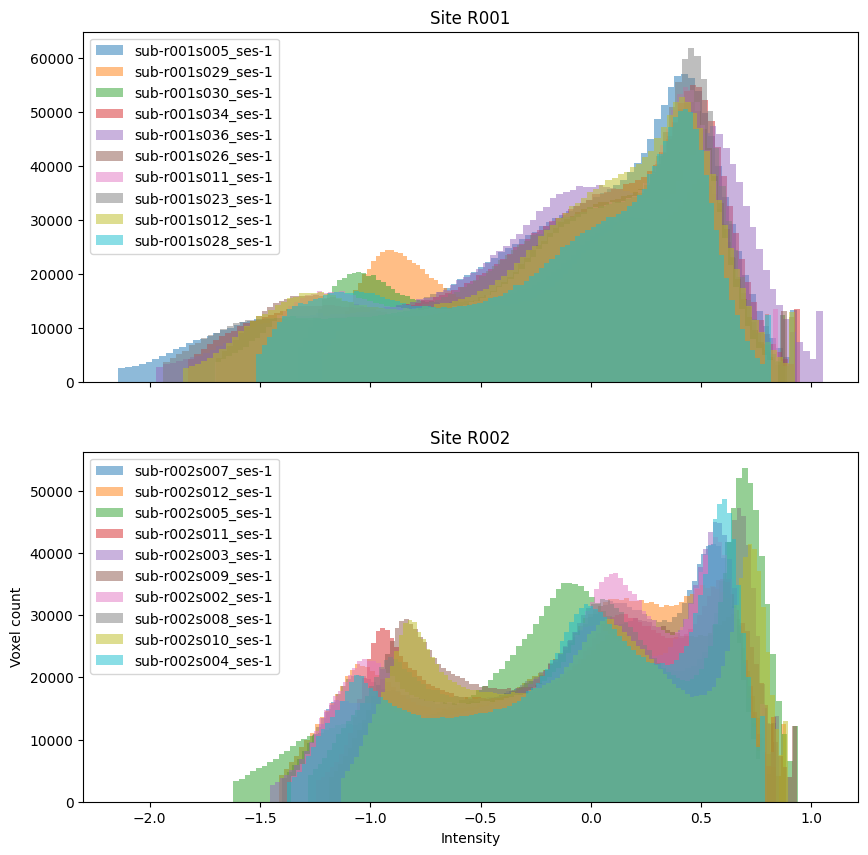

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(10,10), sharex=True)

for key, value in site_r001.items():
    axes[0].hist(value, bins=100, alpha=0.5, label=key) 

for key, value in site_r002.items():
    axes[1].hist(value, bins=100, alpha=0.5, label=key) 

axes[0].set_title("Site R001")
axes[0].legend(loc="upper left")

axes[1].set_title("Site R002")
axes[1].legend(loc="upper left")

plt.xlabel("Intensity")
plt.ylabel("Voxel count")
# plt.title("Brain MRI (robustly scaled) intensity distribution")

plt.show()

## Exploratory analysis of multicenter impact

### Trying to predict site using basic features

In [33]:
def compute_brain_stats(x):
    return {
        "mean": np.mean(x),
        "std": np.std(x),
        "max": np.max(x),
        "min": np.min(x),
        "p01": np.percentile(x, 1),
        "p05": np.percentile(x, 5),
        "p95": np.percentile(x, 95),
        "p99": np.percentile(x, 99)
    }

stats_list = []
for _, row in tqdm(list(df[df["DATASET"] == "Training"].iterrows())):
    t1w_filepath = f"{ATLAS_PREPROCESSED_DATASET_FOLDER}/" + row["T1W FILEPATH"]
    site = row["SITE"]
    t1w_array = nib.load(t1w_filepath).get_fdata()

    # removing background
    t1w_array = t1w_array[t1w_array > 0]
    
    # robust scaling
    robust_scaled_t1w_array = RobustScaler().fit_transform(t1w_array.reshape(-1, 1))
    
    stats = compute_brain_stats(robust_scaled_t1w_array)
    stats["site"] = site
    stats_list.append(stats)

stats_df = pd.DataFrame([ d.values() for d in stats_list], columns=stats_list[0].keys())

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 653/653 [06:17<00:00,  1.73it/s]


<Axes: >

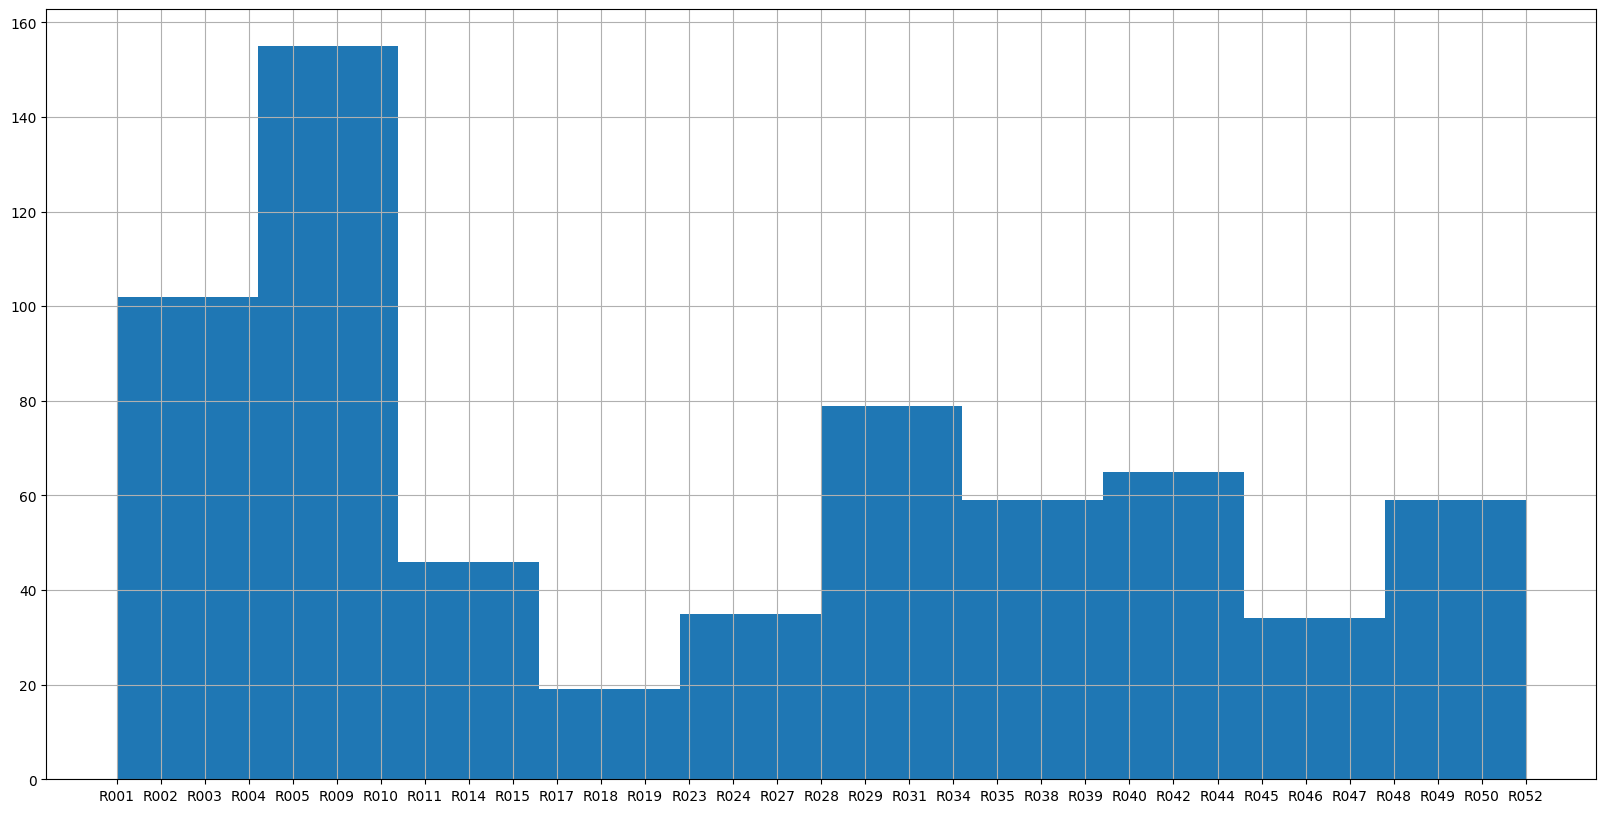

In [50]:
stats_df["site"].hist(figsize=(20,10))

In [51]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

X = stats_df[["mean", "std", "max", "min", "p01", "p05", "p95", "p99"]].to_numpy()
y = stats_df["site"].to_numpy()

pipeline = Pipeline([
    ("svm", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale"
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="balanced_accuracy"
)

print("Accuracy:", scores.mean())
print("Std:", scores.std())

Accuracy: 0.10152132095347384
Std: 0.0025630509126557646


/home/gianluca/.venvs/mri_brain3.10/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


In [6]:


first_order_feature_names = [
    '10Percentile',
    '90Percentile',
    #'Energy',
    #'Entropy',
    'InterquartileRange',
    'Kurtosis',
    'Maximum',
    #'MeanAbsoluteDeviation',
    'Mean',
    'Median',
    'Minimum',
    'Range',
    #'RobustMeanAbsoluteDeviation',
    #'RootMeanSquared',
    'Skewness',
    #'TotalEnergy',
    #'Uniformity',
    'Variance'
]

extractor = featureextractor.RadiomicsFeatureExtractor()
extractor.disableAllFeatures()
extractor.enableFeatureClassByName('firstorder')

radiomic_array = []
site_array = []
t1w_shape = (197, 233, 189)
for _, row in tqdm(list(df[df["DATASET"] == "Training"].iterrows())):
    t1w_filepath = f"{ATLAS_PREPROCESSED_DATASET_FOLDER}/{row['T1W FILEPATH']}"
    site = row['SITE']
    t1w_array = nib.load(t1w_filepath).get_fdata()

    # apply robust scaling
    t1w_array = RobustScaler().fit_transform(t1w_array.reshape(-1, 1)).reshape(t1w_shape)
    
    t1w_sitk_image = sitk.GetImageFromArray(t1w_array)
    sitk_mask = sitk.GetImageFromArray((t1w_array > 0).astype(np.uint8))
    
    result = extractor.execute(t1w_sitk_image, sitk_mask)
    features = []
    for key, value in result.items():
        if not key.startswith('diagnostics_'):
            features.append(value)
    
    radiomic_array.append(features)
    site_array.append(site)

radiomic_array = np.array(radiomic_array)
site_array = np.array(site_array)
site_array = site_array.reshape(-1,1)

 11%|████████████▏                                                                                                 | 72/653 [04:15<34:21,  3.55s/it]


KeyboardInterrupt: 

In [ ]:
radiomic_df = pd.DataFrame(
    radiomic_array, 
    columns=first_order_feature_names
)
radiomic_df["SITE"] = site_array
radiomic_df.head(5)

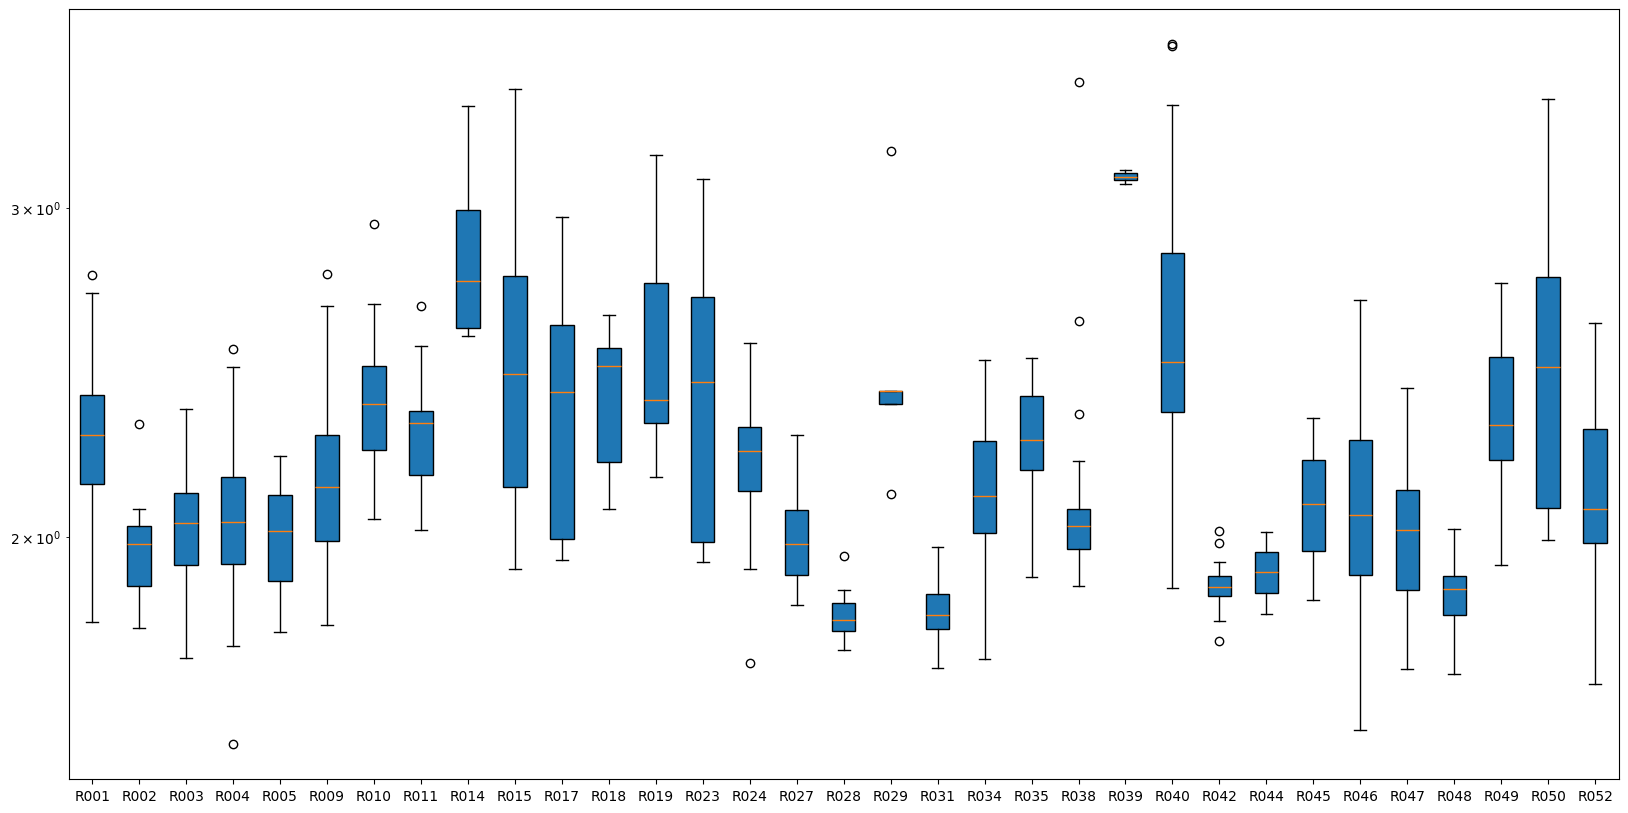

In [180]:
radiomic_feature = "Kurtosis"

l = []
for site in radiomic_df["SITE"].unique():
    l.append(radiomic_df[radiomic_df["SITE"] == site][radiomic_feature].to_list())

fig, ax = plt.subplots(figsize=(20,10))

ax.set_yscale('log')

_ = ax.boxplot(l, patch_artist=True, tick_labels=radiomic_df["SITE"].unique())

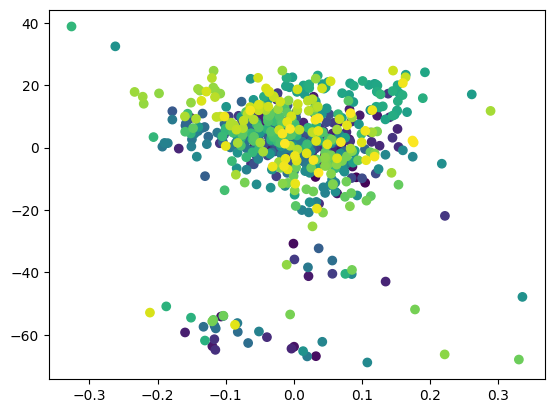

In [113]:
pca = PCA(n_components=10)

X_pca = pca.fit_transform(radiomic_array)
plt.scatter(X_pca[:,9], X_pca[:,2], c=range(len(site_array)))